<a href="https://colab.research.google.com/github/DeepandraSingh1225/Machine-lerning/blob/main/Magic_gamma_telescope.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


#Dataset
- https://archive.ics.uci.edu/dataset/159/magic+gamma+telescope

Additional Variable Information

    - 1.  fLength:  continuous  # major axis of ellipse [mm]
    - 2.  fWidth:   continuous  # minor axis of ellipse [mm]
    - 3.  fSize:    continuous  # 10-log of sum of content of all pixels [in #phot]
    - 4.  fConc:    continuous  # ratio of sum of two highest pixels over fSize  [ratio]
    - 5.  fConc1:   continuous  # ratio of highest pixel over fSize  [ratio]
    - 6.  fAsym:    continuous  # distance from highest pixel to center, projected onto major axis [mm]
    - 7.  fM3Long:  continuous  # 3rd root of third moment along major axis  [mm]
    - 8.  fM3Trans: continuous  # 3rd root of third moment along minor axis  [mm]
    - 9.  fAlpha:   continuous  # angle of major axis with vector to origin [deg]
    - 10.  fDist:    continuous  # distance from origin to center of ellipse [mm]
    - 11.  class:    g,h         # gamma (signal), hadron (background)

   - g = gamma (signal):     12332
   - h = hadron (background): 6688

   - For technical reasons, the number of h events is underestimated. In the real data, the h class represents the majority of the events.



In [8]:
df = pd.read_csv('magic04.data')
df

,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.011,-8.2027,40.092,81.8828,g
0,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
1,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
2,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
3,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g
4,51.6240,21.1502,2.9085,0.2420,0.1340,50.8761,43.1887,9.8145,3.6130,238.0980,g
...,...,...,...,...,...,...,...,...,...,...,...
19014,21.3846,10.9170,2.6161,0.5857,0.3934,15.2618,11.5245,2.8766,2.4229,106.8258,h
19015,28.9452,6.7020,2.2672,0.5351,0.2784,37.0816,13.1853,-2.9632,86.7975,247.4560,h
19016,75.4455,47.5305,3.4483,0.1417,0.0549,-9.3561,41.0562,-9.4662,30.2987,256.5166,h
19017,120.5135,76.9018,3.9939,0.0944,0.0683,5.8043,-93.5224,-63.8389,84.6874,408.3166,h


- we don't have Attributes name or column name in this data set so we add this in our df

In [9]:
labels = ["fLength", "fWidth", "fSize", "fConc", "fConc1", "fAsym", "fM3Long", "fM3Trans", "fAlpha", "fDist", "class"]

# df = pd.read_csv('magic04.data' , names=labels)
# df.head()

# OR


df.columns = labels
df.head()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.261,g
1,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.788,g
2,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.737,g
3,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.462,g
4,51.6240,21.1502,2.9085,0.2420,0.1340,50.8761,43.1887,9.8145,3.6130,238.098,g


- we can clearly see that we have class 'g' and 'h'

In [10]:
df['class'].unique()

array(['g', 'h'], dtype=object)

- our computer don't understand calegorical data so we have to conver this g and h into numbers or numerical data

In [11]:
df['class'] = (df['class'] == 'g').astype(int)      # g = 1 and h = 0

In [12]:
df.head()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.261,1
1,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.788,1
2,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.737,1
3,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.462,1
4,51.6240,21.1502,2.9085,0.2420,0.1340,50.8761,43.1887,9.8145,3.6130,238.098,1


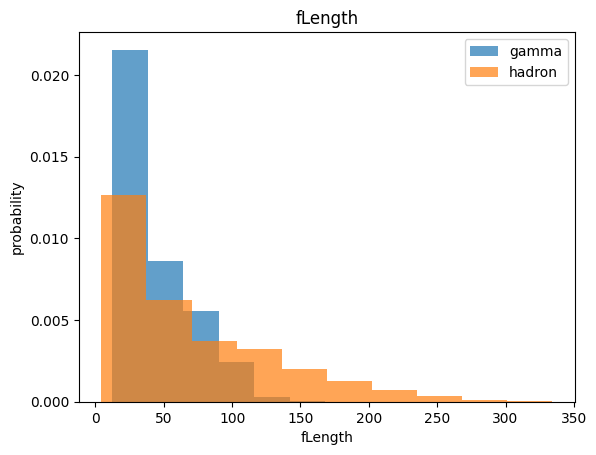

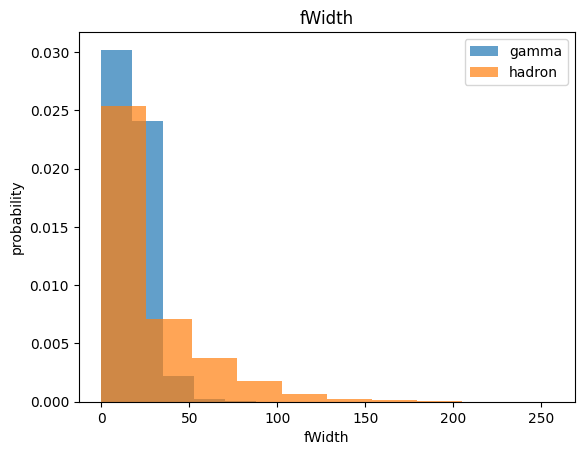

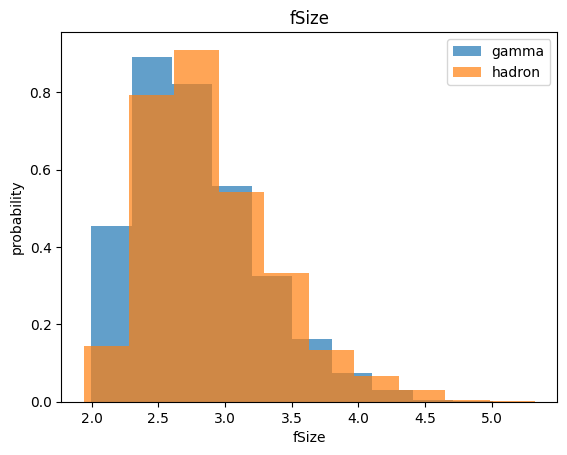

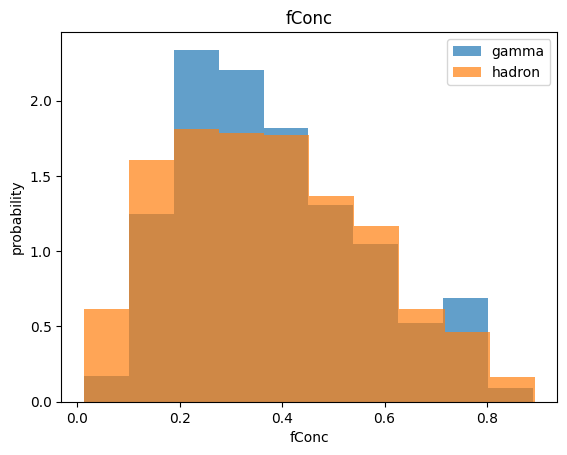

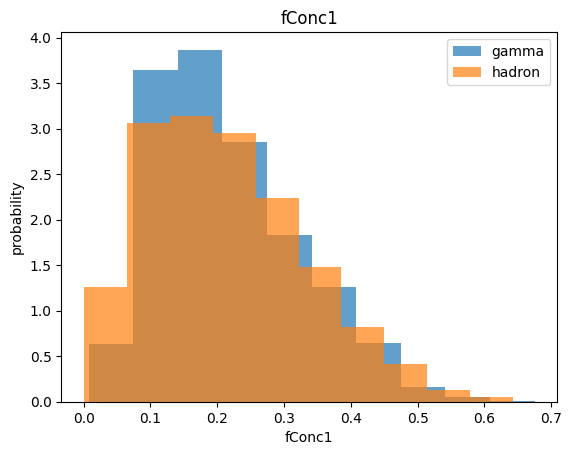

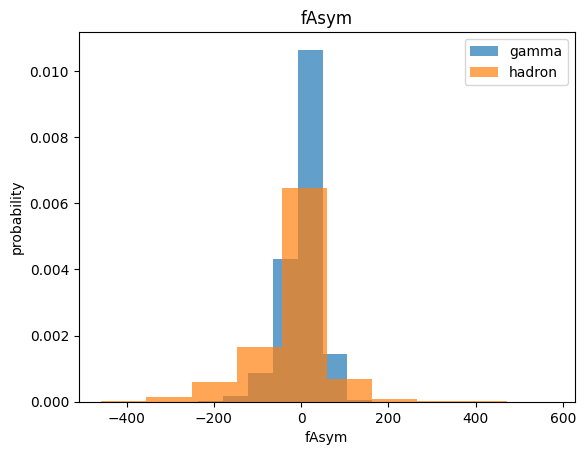

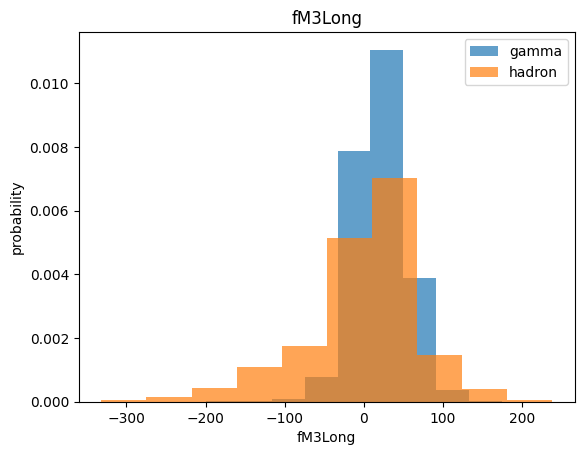

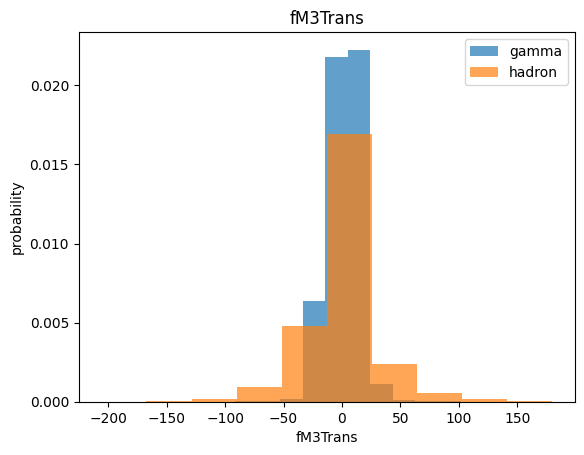

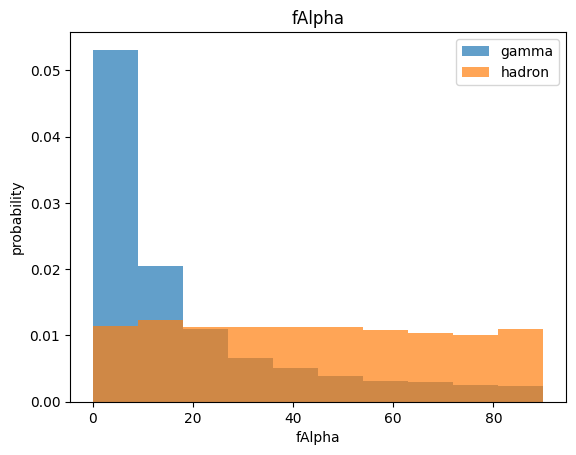

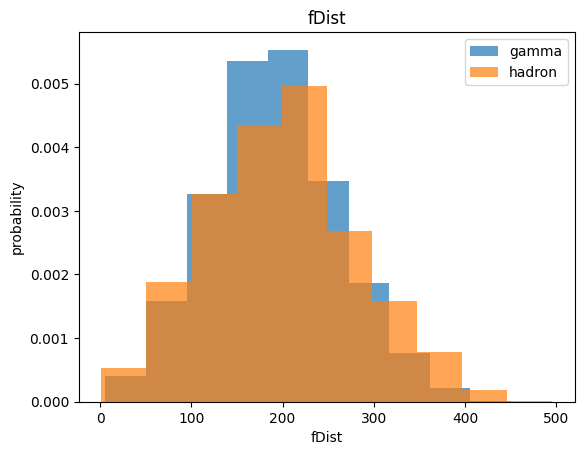

In [13]:
for label in labels[:-1]:  # run on each feature except class

  plt.hist(df[df['class'] == 1][label] , label='gamma' , alpha = 0.7 , density=True)
  plt.hist(df[df['class'] == 0][label] ,  label='hadron' , alpha = 0.7 , density=True)
  # this line f[df['class'] == 1][label]  all the features or label where class is 1

  plt.title(label)
  plt.ylabel('probability')
  plt.xlabel(label)
  plt.legend()
  plt.show()
